In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [2]:
file_path = "Air_Traffic_Passenger_Statistics.csv"  # same folder as notebook

df_raw = pd.read_csv(file_path)
df_raw.head()

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM


In [3]:
df_raw.columns

Index(['Activity Period', 'Activity Period Start Date', 'Operating Airline',
       'Operating Airline IATA Code', 'Published Airline',
       'Published Airline IATA Code', 'GEO Summary', 'GEO Region',
       'Activity Type Code', 'Price Category Code', 'Terminal',
       'Boarding Area', 'Passenger Count', 'data_as_of', 'data_loaded_at'],
      dtype='object')

In [4]:
list(df_raw.columns)

['Activity Period',
 'Activity Period Start Date',
 'Operating Airline',
 'Operating Airline IATA Code',
 'Published Airline',
 'Published Airline IATA Code',
 'GEO Summary',
 'GEO Region',
 'Activity Type Code',
 'Price Category Code',
 'Terminal',
 'Boarding Area',
 'Passenger Count',
 'data_as_of',
 'data_loaded_at']

In [5]:
df_raw = df_raw  # just to be sure it's in memory
print(df_raw.columns.tolist())
df_raw.head(3)

['Activity Period', 'Activity Period Start Date', 'Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Activity Type Code', 'Price Category Code', 'Terminal', 'Boarding Area', 'Passenger Count', 'data_as_of', 'data_loaded_at']


,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM


In [6]:
df = df_raw.rename(columns={
    "ACTIVITY PERIOD": "activity_period",
    "PASSENGER_COUNT": "passenger_count"
})

In [7]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert passenger_count to numeric
df["passenger_count"] = pd.to_numeric(df["passenger_count"], errors="coerce")

# Convert activity_period to datetime
df["activity_period"] = pd.to_datetime(
    df["activity_period"].astype(str),
    format="%Y%m",
    errors="coerce"
)

# Check dataframe
df.head()

,activity_period,activity_period_start_date,operating_airline,operating_airline_iata_code,published_airline,published_airline_iata_code,geo_summary,geo_region,activity_type_code,price_category_code,terminal,boarding_area,passenger_count,data_as_of,data_loaded_at
0,1999-07-01,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
1,1999-07-01,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
2,1999-07-01,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
3,1999-07-01,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM
4,1999-07-01,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2026/04/20 01:00:33 PM,2026/04/22 03:04:52 PM


In [8]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39755 entries, 0 to 39754
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   activity_period              39755 non-null  datetime64[ns]
 1   activity_period_start_date   39755 non-null  object        
 2   operating_airline            39755 non-null  object        
 3   operating_airline_iata_code  39439 non-null  object        
 4   published_airline            39755 non-null  object        
 5   published_airline_iata_code  39439 non-null  object        
 6   geo_summary                  39755 non-null  object        
 7   geo_region                   39755 non-null  object        
 8   activity_type_code           39755 non-null  object        
 9   price_category_code          39755 non-null  object        
 10  terminal                     39755 non-null  object        
 11  boarding_area                39755 non-nu

In [9]:
# Check missing values
df.isnull().sum()

activity_period                  0
activity_period_start_date       0
operating_airline                0
operating_airline_iata_code    316
published_airline                0
published_airline_iata_code    316
geo_summary                      0
geo_region                       0
activity_type_code               0
price_category_code              0
terminal                         0
boarding_area                    0
passenger_count                  0
data_as_of                       0
data_loaded_at                   0
dtype: int64

In [10]:
# Aggregate monthly passenger totals
monthly_passengers = df.groupby("activity_period")["passenger_count"].sum().reset_index()

# Rename columns
monthly_passengers.columns = ["date", "total_passengers"]

# View data
monthly_passengers.head()

,date,total_passengers
0,1999-07-01,3976746
1,1999-08-01,3972694
2,1999-09-01,3341964
3,1999-10-01,3468846
4,1999-11-01,3145240


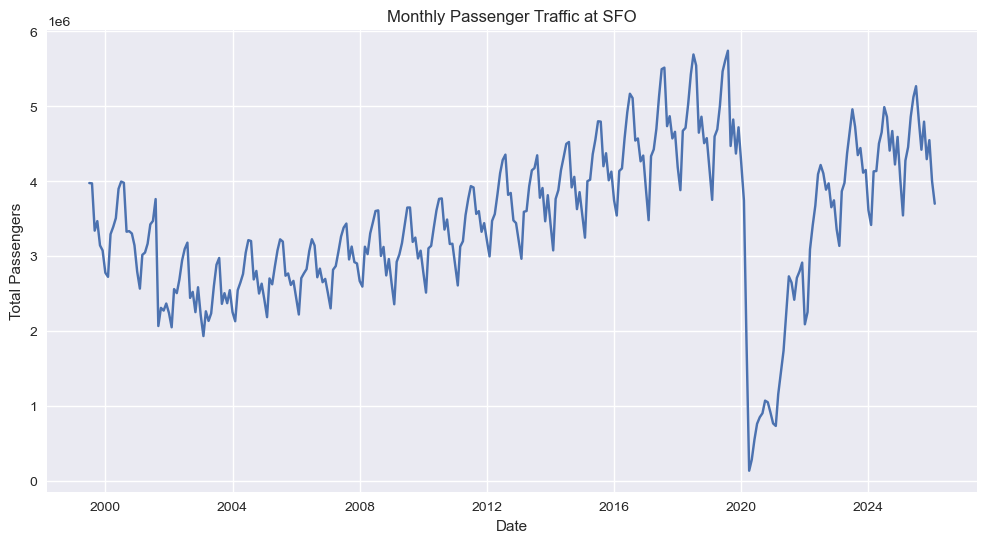

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_passengers["date"], monthly_passengers["total_passengers"])
plt.title("Monthly Passenger Traffic at SFO")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.grid(True)
plt.show()

In [12]:
# Set date as index
monthly_passengers.set_index("date", inplace=True)

# Train-test split
train = monthly_passengers[:'2019']
test = monthly_passengers['2020':]

print(train.shape)
print(test.shape)

(246, 1)
(74, 1)


In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [14]:
# Build SARIMA model
model = SARIMAX(
    train["total_passengers"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

print(results.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                   total_passengers   No. Observations:                  246
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3083.719
Date:                            Fri, 22 May 2026   AIC                           6177.439
Time:                                    00:09:18   BIC                           6194.694
Sample:                                07-01-1999   HQIC                          6184.397
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2805      0.404     -0.695      0.487      -1.072       0.511
ma.L1          0.1873      0.411   

In [15]:
# Forecast for test period
forecast = results.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    typ='levels'
)

forecast.index = test.index

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [16]:
# Generate forecast
forecast = results.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    typ='levels'
)

# Match forecast index with test data
forecast.index = test.index

# View forecast values
forecast.head()

date
2020-01-01    4.292810e+06
2020-02-01    3.930146e+06
2020-03-01    4.723774e+06
2020-04-01    4.805895e+06
2020-05-01    5.112387e+06
Name: predicted_mean, dtype: float64

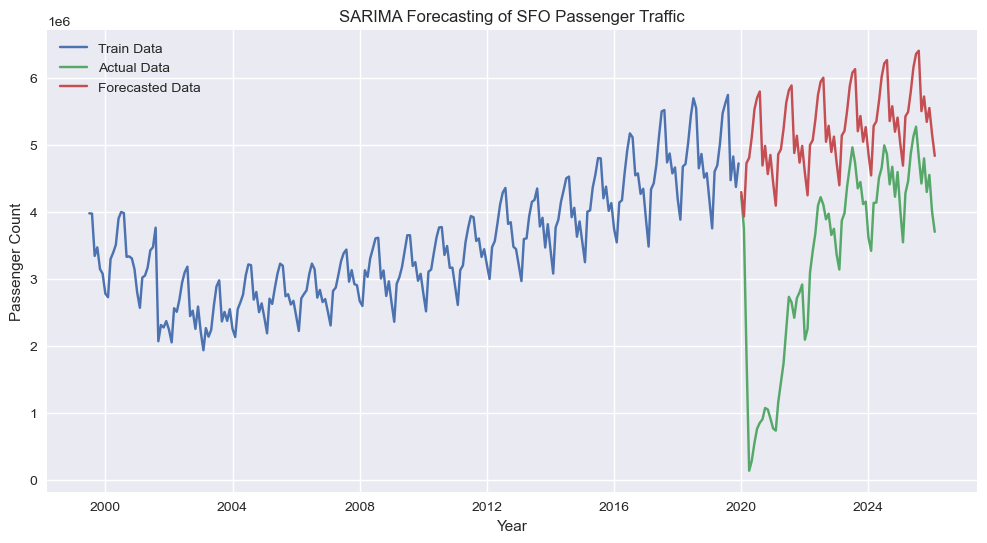

In [17]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["total_passengers"], label="Train Data")
plt.plot(test.index, test["total_passengers"], label="Actual Data")
plt.plot(forecast.index, forecast, label="Forecasted Data")

plt.title("SARIMA Forecasting of SFO Passenger Traffic")
plt.xlabel("Year")
plt.ylabel("Passenger Count")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["total_passengers"], forecast)
rmse = np.sqrt(mean_squared_error(test["total_passengers"], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1911817.5370454127
RMSE: 2271645.254132929


In [19]:
# Forecast next 24 months
future_forecast = results.forecast(steps=24)

# View forecast
future_forecast

2020-01-01    4.292810e+06
2020-02-01    3.930146e+06
2020-03-01    4.723774e+06
2020-04-01    4.805895e+06
2020-05-01    5.112387e+06
2020-06-01    5.528411e+06
2020-07-01    5.699808e+06
2020-08-01    5.792373e+06
2020-09-01    4.690538e+06
2020-10-01    4.981864e+06
2020-11-01    4.562427e+06
2020-12-01    4.847408e+06
2021-01-01    4.437550e+06
2021-02-01    4.091474e+06
2021-03-01    4.857500e+06
2021-04-01    4.932631e+06
2021-05-01    5.234493e+06
2021-06-01    5.626707e+06
2021-07-01    5.812475e+06
2021-08-01    5.884110e+06
2021-09-01    4.876543e+06
2021-10-01    5.133422e+06
2021-11-01    4.733297e+06
2021-12-01    4.981758e+06
Freq: MS, Name: predicted_mean, dtype: float64

In [20]:
# Create future date index
future_dates = pd.date_range(
    start=monthly_passengers.index[-1],
    periods=25,
    freq='M'
)[1:]

C:\Users\Divya Anil Kale\AppData\Local\Temp\ipykernel_9108\2288865986.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


In [21]:
# Create future date index
future_dates = pd.date_range(
    start=monthly_passengers.index[-1],
    periods=25,
    freq='ME'
)[1:]

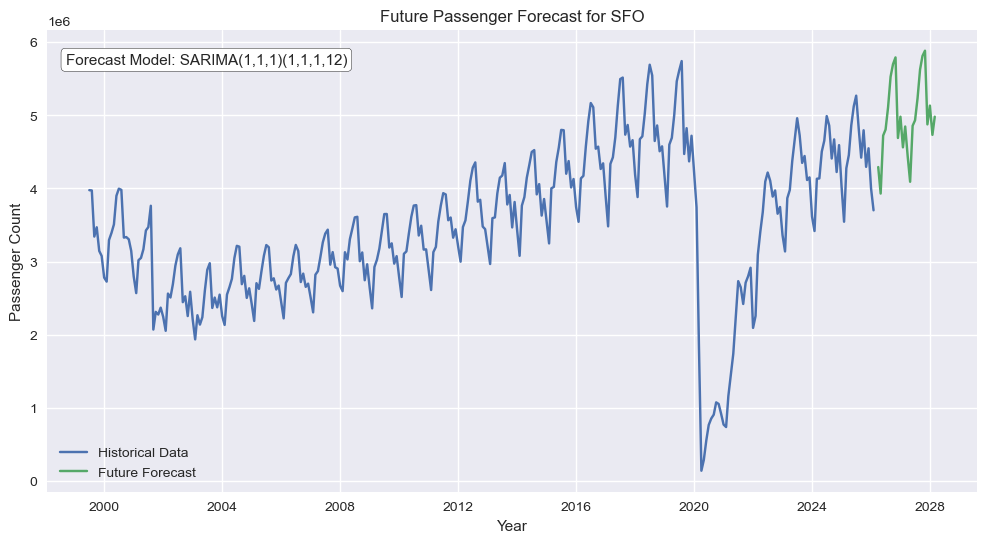

In [22]:
plt.figure(figsize=(12,6))

# Historical data
plt.plot(monthly_passengers.index,
         monthly_passengers["total_passengers"],
         label="Historical Data")

# Future forecast
plt.plot(future_dates,
         future_forecast,
         label="Future Forecast")

plt.title("Future Passenger Forecast for SFO")
plt.xlabel("Year")
plt.ylabel("Passenger Count")

plt.text(
    0.02,
    0.95,
    "Forecast Model: SARIMA(1,1,1)(1,1,1,12)",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white")
)
plt.legend()
plt.grid(True)

plt.show()

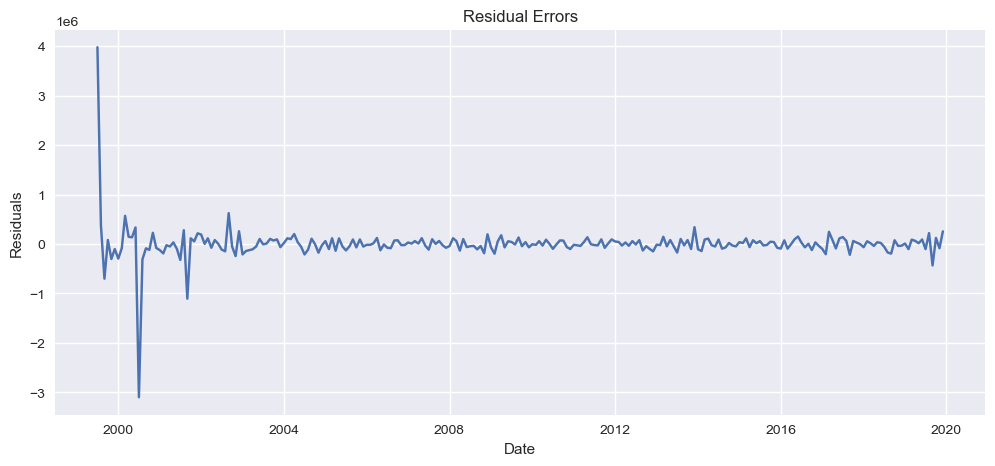

In [23]:
# Residual analysis
residuals = results.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)

plt.title("Residual Errors")
plt.xlabel("Date")
plt.ylabel("Residuals")

plt.grid(True)
plt.show()

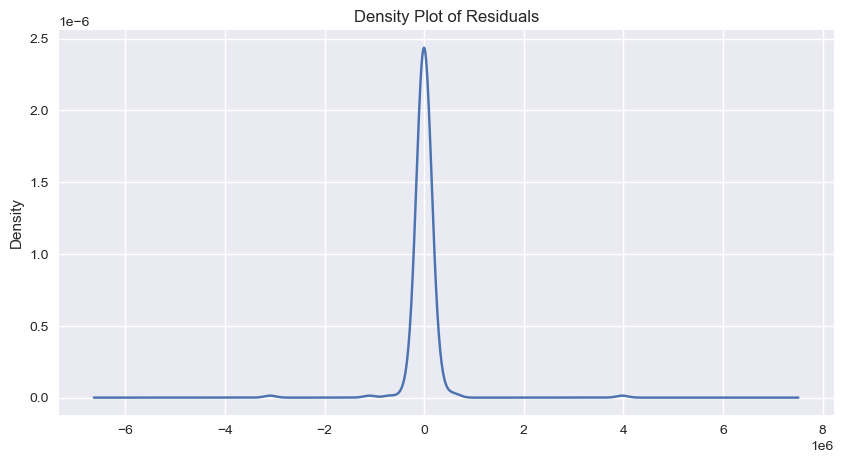

In [24]:
residuals.plot(kind='kde', figsize=(10,5))

plt.title("Density Plot of Residuals")
plt.grid(True)

plt.show()

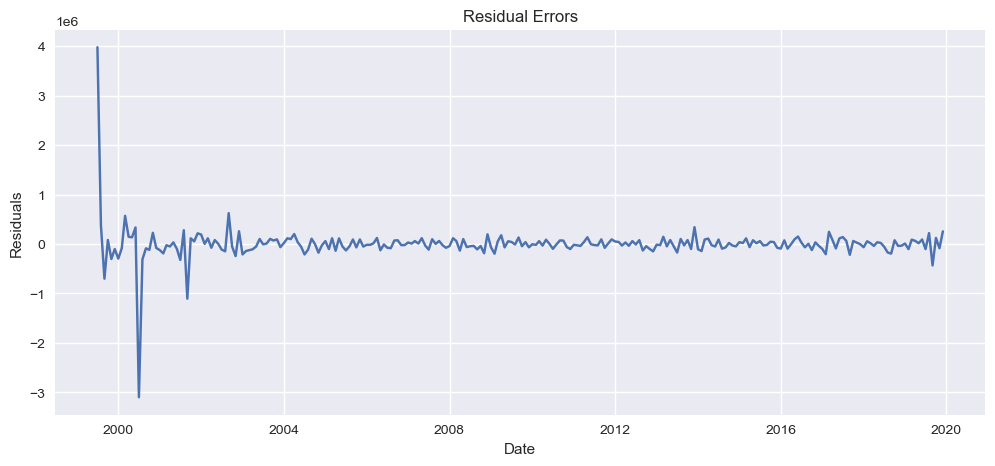

In [25]:
# Residual analysis
residuals = results.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)

plt.title("Residual Errors")
plt.xlabel("Date")
plt.ylabel("Residuals")

plt.grid(True)
plt.show()

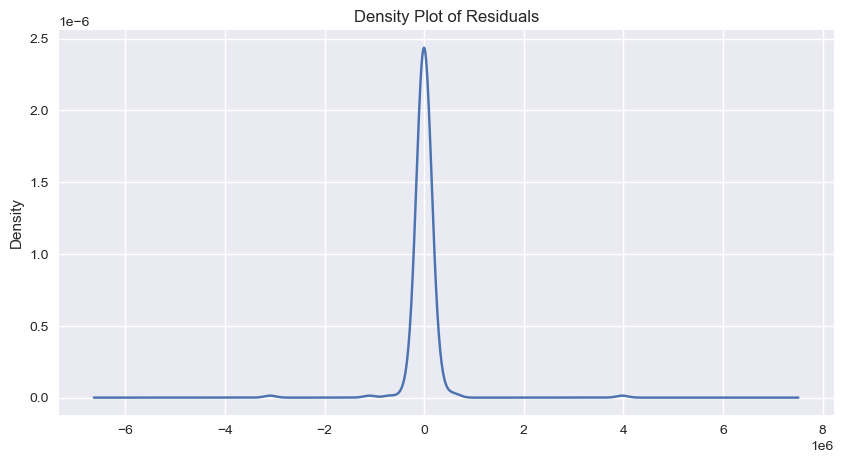

In [26]:
# Density plot of residuals
residuals.plot(kind='kde', figsize=(10,5))

plt.title("Density Plot of Residuals")
plt.grid(True)

plt.show()

In [27]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Actual": test["total_passengers"],
    "Forecast": forecast
})

# Display first rows
comparison_df.head()

,Actual,Forecast
date,,
2020-01-01,4241751,4.292810e+06
2020-02-01,3742224,3.930146e+06
2020-03-01,1885466,4.723774e+06
2020-04-01,138817,4.805895e+06
2020-05-01,286570,5.112387e+06


In [28]:
# Calculate error percentage
comparison_df["Error_Percentage"] = (
    abs(comparison_df["Actual"] - comparison_df["Forecast"])
    / comparison_df["Actual"]
) * 100

comparison_df.head()

,Actual,Forecast,Error_Percentage
date,,,
2020-01-01,4241751,4.292810e+06,1.203715
2020-02-01,3742224,3.930146e+06,5.021679
2020-03-01,1885466,4.723774e+06,150.536138
2020-04-01,138817,4.805895e+06,3362.036081
2020-05-01,286570,5.112387e+06,1683.992326


In [29]:
# Save forecast results
comparison_df.to_csv("sfo_forecast_results.csv")

In [30]:
# Create future forecast dataframe
future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Passengers": future_forecast.values
})

# Display future forecast
future_df.head()

,Date,Predicted_Passengers
0,2026-03-31,4.292810e+06
1,2026-04-30,3.930146e+06
2,2026-05-31,4.723774e+06
3,2026-06-30,4.805895e+06
4,2026-07-31,5.112387e+06


In [31]:
# Save future forecast
future_df.to_csv("future_passenger_forecast.csv", index=False)

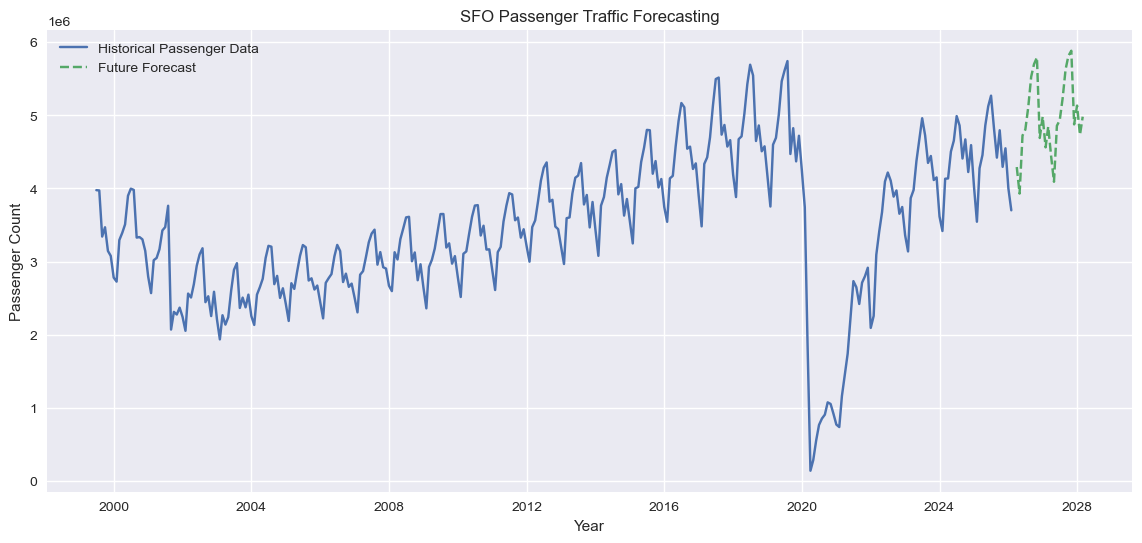

In [32]:
plt.figure(figsize=(14,6))

# Historical data
plt.plot(monthly_passengers.index,
         monthly_passengers["total_passengers"],
         label="Historical Passenger Data")

# Forecasted future data
plt.plot(future_dates,
         future_forecast,
         linestyle='dashed',
         label="Future Forecast")

plt.title("SFO Passenger Traffic Forecasting")
plt.xlabel("Year")
plt.ylabel("Passenger Count")

plt.legend()
plt.grid(True)

plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(test["total_passengers"], forecast)
rmse = np.sqrt(mean_squared_error(test["total_passengers"], forecast))

# Print metrics
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 1911817.5370454127
Root Mean Squared Error (RMSE): 2271645.254132929


In [34]:
# Mean Absolute Percentage Error
mape = np.mean(
    np.abs((test["total_passengers"] - forecast) / test["total_passengers"])
) * 100

print("Mean Absolute Percentage Error (MAPE):", mape)

Mean Absolute Percentage Error (MAPE): 174.29136467601302


In [1]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
!streamlit --version

Streamlit, version 1.45.1
